FILTERING

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from pathlib import Path
from sklearn.metrics import pairwise_distances_argmin_min
import shutil
import hdbscan
from sklearn.metrics import silhouette_score, silhouette_samples
import sys

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
np.set_printoptions(threshold=sys.maxsize)

AUDIO_FEATURES_CSV_PATH=Path("audio_samples_features_for_filtering.csv")

SOURCE_DIR = Path("AudioSamples")
OUTPUT_BASE_DIR = Path("Clustered_Audio")
FILTERED_DIR=Path("AudioSamplesFiltered")
CSV_METADATA_PATH = Path("audio_samples_metadata.csv")
CSV_OUTPUT_PATH = Path("audio_samples_filtered_metadata.csv")

PREFERRED_CLUSTERING_TECHNIQUE = "hdbscan"
PREFERRED_CLUSTER = 0  # Cambia in base al cluster che vuoi filtrare

KMEANS_NUM_CLUSTERS = 2


In [3]:
if OUTPUT_BASE_DIR.exists():
    shutil.rmtree(OUTPUT_BASE_DIR)  # Rimuove la cartella e tutto il contenuto

OUTPUT_BASE_DIR.mkdir(parents=True) # La ricrea vuota

In [4]:
if FILTERED_DIR.exists():
    shutil.rmtree(FILTERED_DIR)  # Rimuove la cartella e tutto il contenuto

FILTERED_DIR.mkdir(parents=True) # La ricrea vuota

In [5]:
df = pd.read_csv(AUDIO_FEATURES_CSV_PATH)
metadata_df = pd.read_csv(CSV_METADATA_PATH)

In [6]:
# Identifichiamo le colonne delle feature (tutte tranne il filename)
features_cols = [c for c in df.columns if c != 'filename']

# 2. Pulizia e Standardizzazione
# Gestiamo eventuali valori infiniti o NaN che possono capitare con i Delta
X = df[features_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
k_range = range(2, 16)  # Testiamo da 2 a 10 cluster
inertias = []
silhouettes = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    # Metrica 1: Inerzia (per Elbow Method)
    inertias.append(kmeans.inertia_)
    
    # Metrica 2: Silhouette Score
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouettes.append(silhouette_avg)

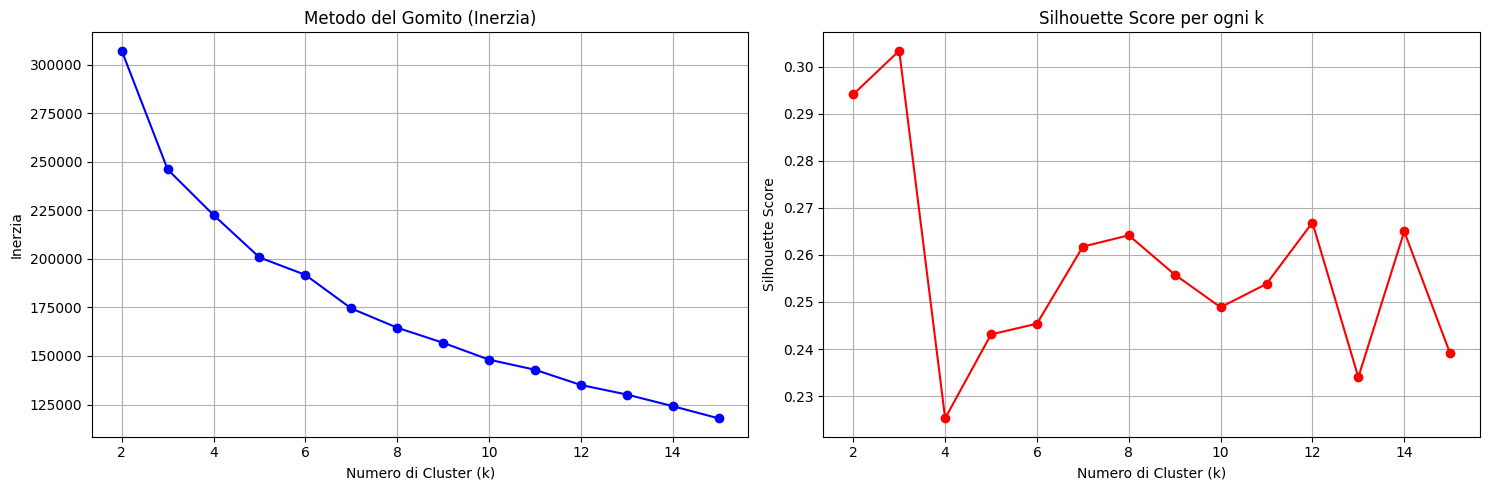

In [8]:
# Creazione del Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot Elbow Method
ax1.plot(k_range, inertias, 'bo-')
ax1.set_title('Metodo del Gomito (Inerzia)')
ax1.set_xlabel('Numero di Cluster (k)')
ax1.set_ylabel('Inerzia')
ax1.grid(True)

# Plot Silhouette Score
ax2.plot(k_range, silhouettes, 'ro-')
ax2.set_title('Silhouette Score per ogni k')
ax2.set_xlabel('Numero di Cluster (k)')
ax2.set_ylabel('Silhouette Score')
ax2.grid(True)

plt.tight_layout()
plt.show()

In [9]:
# 3. K-Means Clustering
kmeans = KMeans(n_clusters=KMEANS_NUM_CLUSTERS, init='k-means++', random_state=42)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

C:\Users\chris\AppData\Local\Temp\ipykernel_20972\329315313.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)


In [10]:
# 1. Calcola lo score individuale per ogni punto
silhouette_vals = silhouette_samples(X_scaled, df['cluster_kmeans'])

# 2. Aggiungi la colonna al dataframe
df['silhouette_score_kmeans'] = silhouette_vals

C:\Users\chris\AppData\Local\Temp\ipykernel_20972\3144363226.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['silhouette_score_kmeans'] = silhouette_vals


In [11]:
# 4. HDBSCAN Clustering
hdbscan_clusterer = hdbscan.HDBSCAN(
    min_cluster_size=20, 
    min_samples=5,
    metric='euclidean',
)
df['cluster_hdbscan'] = hdbscan_clusterer.fit_predict(X_scaled)

C:\Users\chris\AppData\Local\Temp\ipykernel_20972\3739522665.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_hdbscan'] = hdbscan_clusterer.fit_predict(X_scaled)


In [12]:
# 1. Calcola lo score individuale per ogni punto
silhouette_vals = silhouette_samples(X_scaled, df['cluster_hdbscan'])

# 2. Aggiungi la colonna al dataframe
df['silhouette_score_hdbscan'] = silhouette_vals

# 3.Gestione del rumore (-1)
# HDBSCAN assegna -1 ai punti che non appartengono a nessun cluster.
# Il Silhouette Score per loro potrebbe non essere affidabile o calcolabile correttamente.

# Se il cluster è -1 (rumore), impostiamo la confidenza a 0 
# altrimenti usiamo il silhouette score
df['silhouette_score_hdbscan'] = np.where(
    df['cluster_hdbscan'] == -1, 
    0, 
    df['silhouette_score_hdbscan']
)

C:\Users\chris\AppData\Local\Temp\ipykernel_20972\430571821.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['silhouette_score_hdbscan'] = silhouette_vals


In [13]:
# 4. Riduzione dimensionalità per il grafico
# PCA aiuta a vedere la struttura globale dei dati
pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
df['pca_1'] = pca_coords[:, 0]
df['pca_2'] = pca_coords[:, 1]

C:\Users\chris\AppData\Local\Temp\ipykernel_20972\3411096995.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['pca_1'] = pca_coords[:, 0]
C:\Users\chris\AppData\Local\Temp\ipykernel_20972\3411096995.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['pca_2'] = pca_coords[:, 1]


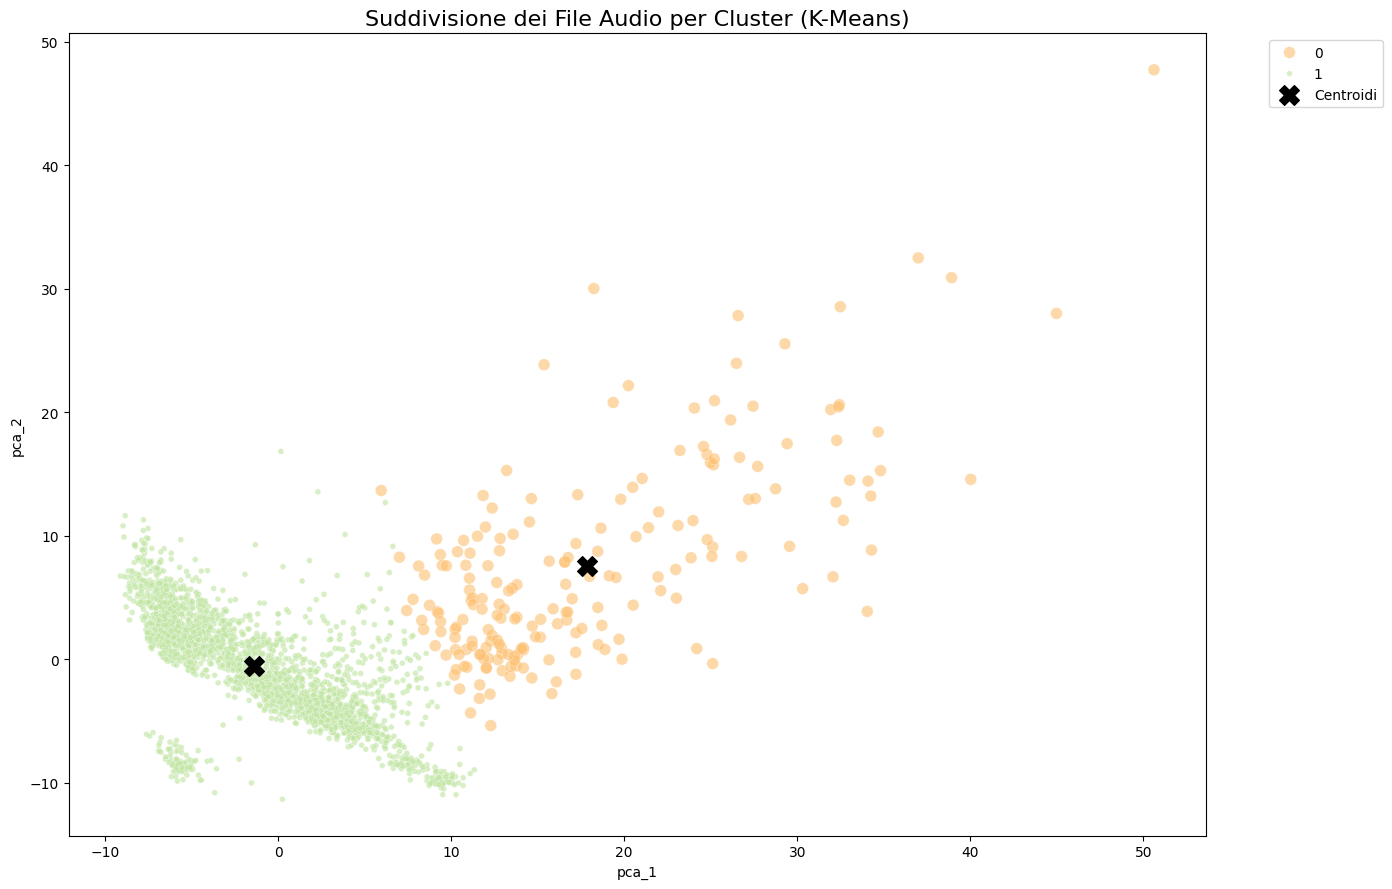

In [14]:
# 5. Visualizzazione Avanzata
plt.figure(figsize=(14, 9))
sns.scatterplot(
    x="pca_1", y="pca_2",
    hue="cluster_kmeans",
    size="cluster_kmeans", # Aiuta a distinguere i gruppi sovrapposti
    palette="Spectral",
    data=df,
    alpha=0.6,
    edgecolor='w'
)

# Aggiungiamo i centroidi dei cluster per chiarezza
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
            s=200, c='black', marker='X', label='Centroidi')

plt.title("Suddivisione dei File Audio per Cluster (K-Means)", fontsize=16)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

C:\Users\chris\AppData\Local\Temp\ipykernel_20972\3281874729.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['legenda_cluster_hdbscan'] = df['cluster_hdbscan'].apply(


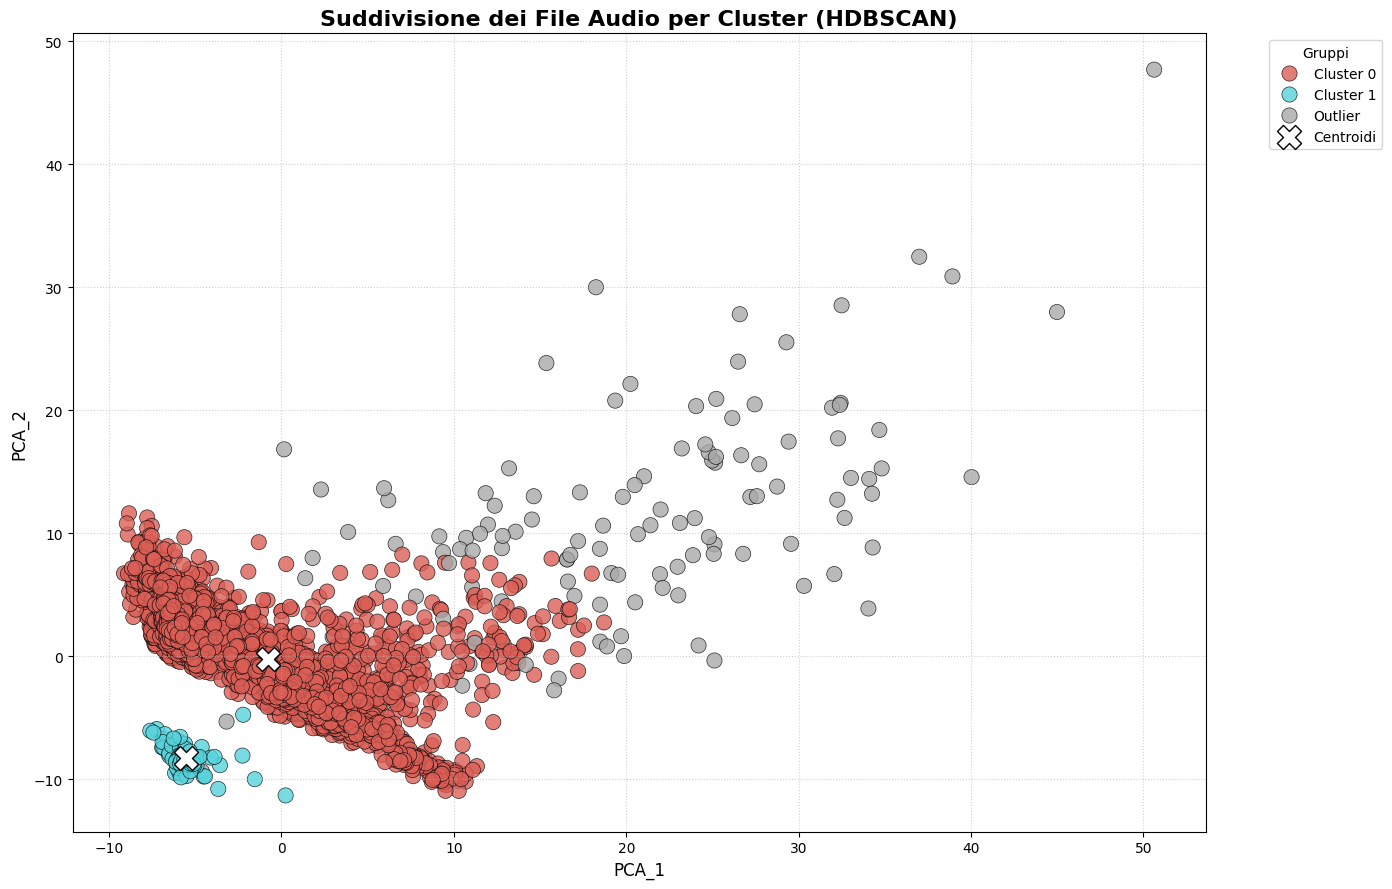

In [15]:
# Creazione colonna legenda
df['legenda_cluster_hdbscan'] = df['cluster_hdbscan'].apply(
    lambda x: 'Outlier' if x == -1 else f'Cluster {x}'
)

# --- CONFIGURAZIONE COLORI VIVACI ---
# Otteniamo la lista dei cluster reali (escludendo l'outlier per la palette)
nomi_cluster_reali = sorted([n for n in df['legenda_cluster_hdbscan'].unique() if n != 'Outlier'])
n_reali = len(nomi_cluster_reali)

# Generiamo colori molto saturi (HLS è ottimo per colori vividi)
colori_vividi = sns.color_palette("hls", n_reali)

# Costruiamo il dizionario finale
color_dict = {nome: colori_vividi[i] for i, nome in enumerate(nomi_cluster_reali)}
color_dict['Outlier'] = '#A9A9A9'  # Grigio scuro per contrasto con i colori accesi

# --- 5. Visualizzazione ---
plt.figure(figsize=(14, 9))

# Scatter plot con colori saturati
sns.scatterplot(
    x="pca_1", 
    y="pca_2",
    hue="legenda_cluster_hdbscan",
    palette=color_dict,
    hue_order=nomi_cluster_reali + (['Outlier'] if 'Outlier' in df['legenda_cluster_hdbscan'].values else []),
    data=df,
    alpha=0.8,         # Aumentata opacità per colori più carichi
    edgecolor='black', # Bordo nero per far "staccare" i punti
    linewidth=0.5,
    s=120              # Punti leggermente più grandi
)

# --- CALCOLO CENTROIDI ---
unique_clusters = [c for c in df['cluster_hdbscan'].unique() if c != -1]
if len(unique_clusters) > 0:
    centroids_pca = np.array([
        df[df['cluster_hdbscan'] == c][['pca_1', 'pca_2']].mean().values 
        for c in unique_clusters
    ])
    
    plt.scatter(
        centroids_pca[:, 0], 
        centroids_pca[:, 1], 
        s=300, 
        c='white',     # Bianco con bordo nero per contrastare i colori vivaci
        marker='X', 
        edgecolors='black',
        label='Centroidi',
        zorder=10
    )

# --- ESTETICA ASSI ---
plt.title("Suddivisione dei File Audio per Cluster (HDBSCAN)", fontsize=16, fontweight='bold')
plt.xlabel("PCA_1", fontsize=12)
plt.ylabel("PCA_2", fontsize=12)

plt.legend(title="Gruppi", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()

plt.show()

In [16]:
# Conteggio per HDBSCAN
print("--- CONTEGGIO CAMPIONI: HDBSCAN ---")
print(df['cluster_hdbscan'].value_counts().sort_index().rename(index={-1: 'Outlier'}))

print("\n" + "-"*30 + "\n")

# Conteggio per KMeans
print("--- CONTEGGIO CAMPIONI: K-MEANS ---")
print(df['cluster_kmeans'].value_counts().sort_index())

--- CONTEGGIO CAMPIONI: HDBSCAN ---
cluster_hdbscan
Outlier     126
0          2554
1            86
Name: count, dtype: int64

------------------------------

--- CONTEGGIO CAMPIONI: K-MEANS ---
cluster_kmeans
0     198
1    2568
Name: count, dtype: int64


In [17]:
# 1. Calcolo per K-Means (Semplice)
km_labels = df['cluster_kmeans']
score_kmeans = silhouette_score(X, km_labels)
print(f"Silhouette Score K-Means: {score_kmeans:.4f}")

# 2. Calcolo per HDBSCAN (Attenzione al rumore)
# Il Silhouette score non è definito per i punti di rumore (-1). 
# Dobbiamo filtrarli per avere un valore significativo sui cluster trovati.
hdb_labels = df['cluster_hdbscan']
mask = hdb_labels != -1
if mask.any():
    score_hdbscan = silhouette_score(X_scaled[mask], hdb_labels[mask])
    print(f"Silhouette Score HDBSCAN (escluso rumore): {score_hdbscan:.4f}")
else:
    print("HDBSCAN non ha trovato cluster (tutto rumore).")

Silhouette Score K-Means: 0.0181
Silhouette Score HDBSCAN (escluso rumore): 0.3420


In [18]:
filtered_filenames = df[df[f'cluster_{PREFERRED_CLUSTERING_TECHNIQUE}'] == PREFERRED_CLUSTER]["filename"]
filtered_metadata_df = metadata_df[metadata_df['filename'].isin(filtered_filenames)].copy()

filtered_metadata_df.to_csv(CSV_OUTPUT_PATH, index=False)

In [19]:
# 3. Estrai la lista dei nomi file dal df filtrato
# Assumendo che la colonna si chiami 'filename'
files_to_copy = filtered_metadata_df['filename'].tolist()

print(f"Inizio copia di {len(files_to_copy)} file...")

contatore_successi = 0
contatore_errori = 0

for filename in files_to_copy:
    source_path = SOURCE_DIR / filename
    target_path = FILTERED_DIR / filename
    
    # Verifica se il file esiste nella sorgente
    if source_path.exists():
        shutil.copy2(source_path, target_path)  # copy2 preserva anche i metadati (date, ecc.)
        contatore_successi += 1
    else:
        print(f"File non trovato: {filename}")
        contatore_errori += 1

print(f"Operazione completata!")
print(f"File copiati: {contatore_successi}")
if contatore_errori > 0:
    print(f"File mancanti: {contatore_errori}")

Inizio copia di 2554 file...
Operazione completata!
File copiati: 2554


In [20]:

# Definiamo gli algoritmi e le relative colonne nel DataFrame
algorithms = {
    "HDBSCAN": "cluster_hdbscan",
    "KMeans": "cluster_kmeans"
}

print(f"Inizio smistamento file in {OUTPUT_BASE_DIR}...")

# Iteriamo sui due metodi di clustering
for nome_algoritmo, colonna_cluster in algorithms.items():
    print(f"Elaborazione cartelle per {nome_algoritmo}...")
    
    # 1. Identifichiamo i cluster unici prodotti dall'algoritmo
    cluster_unici = df[colonna_cluster].unique()
    
    for cluster_id in cluster_unici:
        # 2. Creiamo il nome della sottocartella
        # Se è HDBSCAN e il cluster è -1, lo chiamiamo Outliers
        if nome_algoritmo == "HDBSCAN" and cluster_id == -1:
            nome_cartella = "Outliers"
        else:
            nome_cartella = f"Cluster_{cluster_id}"
            
        target_dir = OUTPUT_BASE_DIR / nome_algoritmo / nome_cartella
        target_dir.mkdir(parents=True, exist_ok=True)
        
        # 3. Filtriamo i file appartenenti a questo specifico cluster
        file_nel_cluster = df[df[colonna_cluster] == cluster_id]['filename']
        
        # 4. Copia fisica dei file
        for nome_file in file_nel_cluster:
            src_path = SOURCE_DIR / nome_file
            dest_path = target_dir / nome_file
            
            if src_path.exists():
                shutil.copy2(src_path, dest_path)
            else:
                # Opzionale: stampa se manca qualche file sorgente
                pass

Inizio smistamento file in Clustered_Audio...
Elaborazione cartelle per HDBSCAN...
Elaborazione cartelle per KMeans...


In [21]:
# Ordina il dataframe per vedere i casi più critici in alto
df_check = df.sort_values(by='silhouette_score_kmeans', ascending=True)

# Visualizza i primi 10 file più incerti
print(df_check[(df_check['silhouette_score_kmeans'] != 0) & (df_check['cluster_kmeans'] == 1)][['filename','silhouette_score_kmeans']]
      .head(100))

                           filename  silhouette_score_kmeans
4     audio_2026-02-23T09-29-22.wav                 0.149446
13    audio_2026-02-23T10-35-52.wav                 0.222055
2317  audio_2026-03-15T13-04-31.wav                 0.236906
1030  audio_2026-03-02T18-13-37.wav                 0.241275
2137  audio_2026-03-13T08-56-05.wav                 0.256635
1381  audio_2026-03-09T16-51-54.wav                 0.260318
20    audio_2026-02-23T10-55-30.wav                 0.277611
364   audio_2026-02-24T07-53-38.wav                 0.278443
1543  audio_2026-03-10T09-06-16.wav                 0.307157
27    audio_2026-02-23T11-15-08.wav                 0.312316
2212  audio_2026-03-15T00-52-44.wav                 0.316321
2195  audio_2026-03-14T23-25-52.wav                 0.318591
2313  audio_2026-03-15T12-44-05.wav                 0.321312
2525  audio_2026-03-16T14-02-29.wav                 0.324330
1965  audio_2026-03-12T12-37-44.wav                 0.325736
539   audio_2026-02-24T1

In [22]:
# Ordina il dataframe per vedere i casi più critici in alto
df_check = df.sort_values(by='silhouette_score_hdbscan', ascending=True)

# Visualizza i primi 10 file più incerti
print(df_check[(df_check['silhouette_score_hdbscan'] != 0) & (df_check['cluster_hdbscan'] == 0)][['filename','silhouette_score_hdbscan']]
      .head(100))

                           filename  silhouette_score_hdbscan
27    audio_2026-02-23T11-15-08.wav                  0.116659
1989  audio_2026-03-12T16-02-52.wav                  0.141390
368   audio_2026-02-24T07-58-25.wav                  0.142510
33    audio_2026-02-23T11-44-31.wav                  0.148635
378   audio_2026-02-24T08-33-06.wav                  0.162179
2521  audio_2026-03-16T13-42-03.wav                  0.164305
2557  audio_2026-03-16T17-20-21.wav                  0.164703
24    audio_2026-02-23T11-11-34.wav                  0.165165
599   audio_2026-02-24T19-17-51.wav                  0.165926
1842  audio_2026-03-11T22-54-42.wav                  0.170556
3     audio_2026-02-23T09-28-11.wav                  0.174163
575   audio_2026-02-24T18-48-47.wav                  0.174894
539   audio_2026-02-24T18-05-13.wav                  0.177784
23    audio_2026-02-23T11-10-22.wav                  0.178366
1323  audio_2026-03-04T01-00-45.wav                  0.179931
774   au